In [ ]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
X = 2 * np.random.rand(100,1)



In [ ]:
y = 4 + 3 * X + np.random.randn(100,1) #Rastgele Gaussian (normal dağılım) hatası ekler.


In [ ]:
X_b = np.c_[np.ones((100,1)),X]


###Hiper parametreler

In [ ]:
ögrenme_oranı = 0.1
n_iterations = 1000
veri_sayı = 100

###Ağırlıkların Belirlenmesi

In [ ]:
weights = np.random.randn(2,1)

In [ ]:
for iteration in range(n_iterations):
  gradients = 2/veri_sayı * X_b.T.dot(X_b.dot(weights) - y) # MSE'nin türevi ile gradyanı hesapla
  weights -= ögrenme_oranı * gradients # Ağırlıkları güncelle (Gradyan iniş adımı)

In [ ]:
# Maliyet (kayıp) fonksiyonunu tanımlıyoruz
def compute_cost(X, y, weights):
    m = len(y)  # Veri setindeki örnek sayısı
    predictions = X.dot(weights)  # Modelin tahmin ettiği değerler
    cost = np.sum((predictions - y) ** 2) / (2 * m)  # Ortalama kare hata (MSE) hesaplanıyor
    return cost  # Kayıp değeri döndür

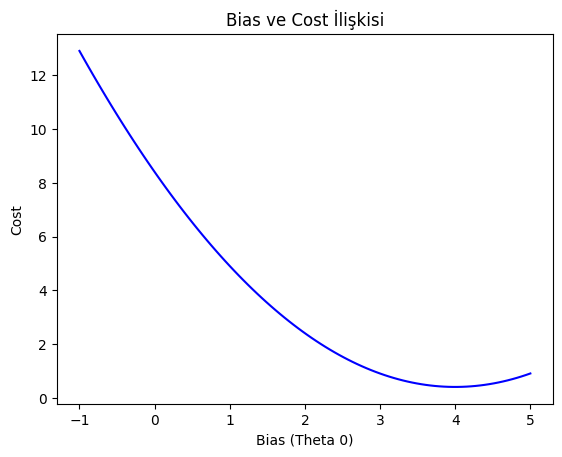

In [ ]:
# Bias (θ₀) değerlerini test etmek için bir aralık oluşturuyoruz
weights_range = np.linspace(-1, 5, 100)  # -1 ile 5 arasında 100 farklı θ₀ değeri oluşturuluyor

# Her bias (θ₀) değeri için maliyet fonksiyonunu hesaplıyoruz
cost_values = [compute_cost(X_b, y, np.array([[w], [3]])) for w in weights_range]
# θ₁ (eğim) sabit olarak 3 alınırken, θ₀ farklı değerler alıyor

# Grafik çizdirme
plt.plot(weights_range, cost_values, 'b-')  # Mavi çizgi ile maliyet grafiğini çiziyoruz
plt.xlabel('Bias (Theta 0)')  # X ekseni etiketi (θ₀)
plt.ylabel('Cost')  # Y ekseni etiketi (MSE kayıp fonksiyonu)
plt.title('Bias ve Cost İlişkisi')  # Grafik başlığı
plt.show()  # Grafiği göster

#Yapay Sinir Ağları

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
giris_verileri = np.array([[0],[1],[2],[3]])
cikis_verileri = np.array([0,2,4,6])

In [ ]:
model = Sequential([
    Dense(units=1, input_shape=(1,))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='sgd',loss='mean_squared_error')

In [ ]:
model.fit(giris_verileri,cikis_verileri, epochs=1000,verbose=0)

In [ ]:
test_verisi = np.array([[4],[5],[6]])

In [ ]:
print("Tahmin sonucu : ",model.predict(test_verisi))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Tahmin sonucu :  [[ 7.9995837]
 [ 9.999361 ]
 [11.999138 ]]


#CART

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
import pandas as pd

In [ ]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['Target'] = iris.target

X = iris.data
y = iris.target

In [ ]:
model = DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

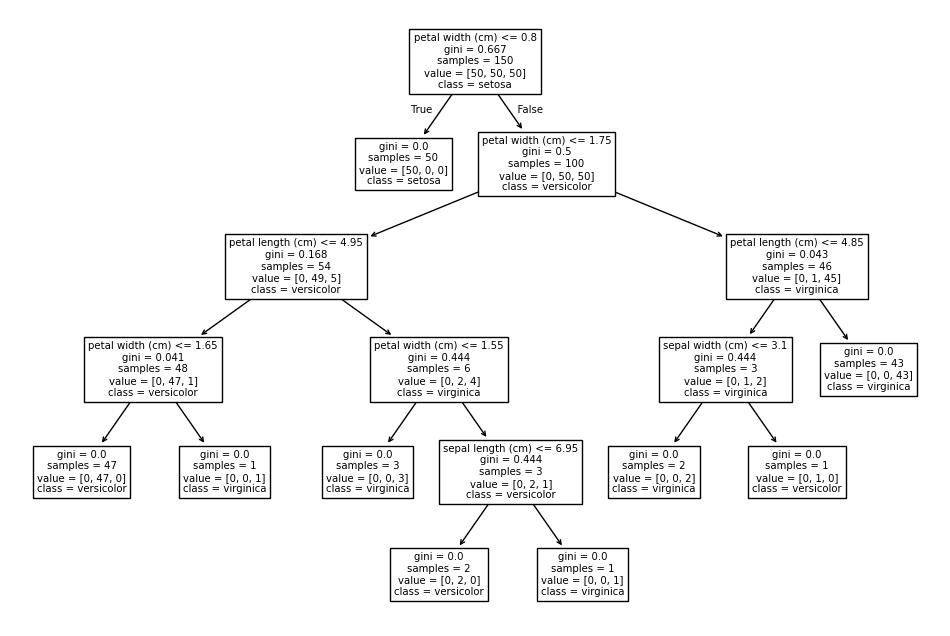

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=100,random_state=34)

In [ ]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=34)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
basari_skoru = accuracy_score(y_test,y_pred)
print("Başarı oranı : ",basari_skoru)

Başarı oranı :  0.9833333333333333


#Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
model = AdaBoostClassifier(n_estimators=10,random_state=34)

In [ ]:
model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=10, random_state=34)

In [ ]:
y_pred = model.predict(X_test)
basari_skoru = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari_skoru)

Başarı skoru :  0.9833333333333333
